In [ ]:
import os
import time
import zipfile
import shutil
import warnings
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
import tensorflow as tf

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score

from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Input, Conv1D, LSTM, GRU, Dense, Dropout, concatenate, Flatten
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

warnings.filterwarnings("ignore")
np.random.seed(42)
tf.random.set_seed(42)

In [ ]:
DATA_URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/00235/household_power_consumption.zip"
ZIP_PATH = "household_power_consumption.zip"
TXT_PATH = "household_power_consumption.txt"

if not os.path.exists(TXT_PATH):
    print("Downloading UCI Dataset...")
    urllib.request.urlretrieve(DATA_URL, ZIP_PATH)
    with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
        zip_ref.extractall()
    print("Download and extraction complete.")

print("Loading dataset...")

df = pd.read_csv(
    TXT_PATH,
    sep=";",
    low_memory=False,
    na_values=["?"]
)

df["Datetime"] = pd.to_datetime(
    df["Date"] + " " + df["Time"],
    format="%d/%m/%Y %H:%M:%S",
    errors="coerce"
)

df.drop(columns=["Date", "Time"], inplace=True)
df.dropna(subset=["Datetime"], inplace=True)
df.set_index("Datetime", inplace=True)

for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.ffill()
df = df.resample("h").mean()

features = ["Global_reactive_power", "Voltage", "Global_intensity"]
target = ["Global_active_power"]

print("Dataset shape after resampling:", df.shape)
print(df[features + target].head())

Download and extraction complete.
Loading dataset...
Dataset shape after resampling: (34589, 7)
                     Global_reactive_power     Voltage  Global_intensity  \
Datetime                                                                   
2006-12-16 17:00:00               0.229000  234.643889         18.100000   
2006-12-16 18:00:00               0.080033  234.580167         15.600000   
2006-12-16 19:00:00               0.085233  233.232500         14.503333   
2006-12-16 20:00:00               0.075100  234.071500         13.916667   
2006-12-16 21:00:00               0.076667  237.158667         13.046667   

                     Global_active_power  
Datetime                                  
2006-12-16 17:00:00             4.222889  
2006-12-16 18:00:00             3.632200  
2006-12-16 19:00:00             3.400233  
2006-12-16 20:00:00             3.268567  
2006-12-16 21:00:00             3.056467  


In [ ]:
split_idx = int(len(df) * 0.8)
train_df = df.iloc[:split_idx].copy()
test_df = df.iloc[split_idx:].copy()

X_scaler = MinMaxScaler()
y_scaler = MinMaxScaler()

train_X_scaled = X_scaler.fit_transform(train_df[features])
train_y_scaled = y_scaler.fit_transform(train_df[target])

test_X_scaled = X_scaler.transform(test_df[features])
test_y_scaled = y_scaler.transform(test_df[target])

def create_sequences(X_data, y_data, lookback):
    X, y = [], []
    for i in range(len(X_data) - lookback):
        X.append(X_data[i:(i + lookback), :])
        y.append(y_data[i + lookback, 0])
    return np.array(X), np.array(y)

LOOKBACK = 24
n_features = train_X_scaled.shape[1]

X_train, y_train = create_sequences(train_X_scaled, train_y_scaled, LOOKBACK)
X_test, y_test = create_sequences(test_X_scaled, test_y_scaled, LOOKBACK)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (27647, 24, 3)
y_train shape: (27647,)
X_test shape: (6894, 24, 3)
y_test shape: (6894,)


In [ ]:
def build_paper_baseline(seq_len, n_feat):
    model = Sequential(name="Paper_Baseline_CNN_LSTM")
    model.add(Conv1D(64, 3, activation='relu', padding='same', input_shape=(seq_len, n_feat)))
    model.add(Conv1D(128, 3, activation='relu', padding='same'))
    model.add(Conv1D(256, 3, activation='relu', padding='same'))
    model.add(Conv1D(128, 3, activation='relu', padding='same'))
    model.add(Conv1D(64, 3, activation='relu', padding='same'))
    model.add(LSTM(64, activation='tanh', return_sequences=True))
    model.add(LSTM(128, activation='tanh', return_sequences=True))
    model.add(LSTM(256, activation='tanh', return_sequences=True))
    model.add(LSTM(128, activation='tanh', return_sequences=True))
    model.add(LSTM(64, activation='tanh', return_sequences=True))
    model.add(LSTM(n_feat, activation='tanh', return_sequences=False))
    model.add(Dropout(0.1))
    model.add(Dense(1, activation='linear'))
    model.compile(optimizer='adam', loss='mse')
    return model

def build_parallel_cnn_lstm(seq_len, n_feat):
    inputs = Input(shape=(seq_len, n_feat), name="Input")
    cnn = Conv1D(64, 3, activation='relu', padding='same')(inputs)
    cnn = Conv1D(128, 3, activation='relu', padding='same')(cnn)
    cnn = Flatten()(cnn)
    cnn = Dense(64, activation='relu')(cnn)

    lstm = LSTM(128, activation='tanh', return_sequences=True)(inputs)
    lstm = LSTM(64, activation='tanh', return_sequences=False)(lstm)

    merged = concatenate([cnn, lstm])
    merged = Dropout(0.2)(merged)
    dense = Dense(32, activation='relu')(merged)
    outputs = Dense(1, activation='linear')(dense)

    model = Model(inputs=inputs, outputs=outputs, name="Parallel_CNN_LSTM")
    model.compile(optimizer='adam', loss='mse')
    return model

def build_cnn_gru(seq_len, n_feat):
    model = Sequential(name="CNN_GRU")
    model.add(Conv1D(64, 3, activation='relu', padding='same', input_shape=(seq_len, n_feat)))
    model.add(Conv1D(128, 3, activation='relu', padding='same'))
    model.add(GRU(128, activation='tanh', return_sequences=True))
    model.add(GRU(64, activation='tanh', return_sequences=False))
    model.add(Dropout(0.2))
    model.add(Dense(1, activation='linear'))
    model.compile(optimizer='adam', loss='mse')
    return model

def build_attention_lstm(seq_len, n_feat):
    inputs = Input(shape=(seq_len, n_feat))
    lstm_out = LSTM(128, return_sequences=True)(inputs)

    attention = Dense(1, activation='tanh')(lstm_out)
    attention = Flatten()(attention)
    attention = tf.keras.layers.Activation('softmax')(attention)
    attention = tf.keras.layers.RepeatVector(128)(attention)
    attention = tf.keras.layers.Permute([2, 1])(attention)

    sent_representation = tf.keras.layers.Multiply()([lstm_out, attention])
    sent_representation = tf.keras.layers.Lambda(lambda xin: tf.keras.backend.sum(xin, axis=1))(sent_representation)

    dense1 = Dense(64, activation='relu')(sent_representation)
    outputs = Dense(1, activation='linear')(dense1)

    model = Model(inputs=inputs, outputs=outputs, name="Attention_LSTM")
    model.compile(optimizer='adam', loss='mse')
    return model

In [ ]:
architectures = [
    build_paper_baseline(LOOKBACK, n_features),
    build_parallel_cnn_lstm(LOOKBACK, n_features),
    build_cnn_gru(LOOKBACK, n_features),
    build_attention_lstm(LOOKBACK, n_features)
]

os.makedirs("saved_models", exist_ok=True)
os.makedirs("checkpoints", exist_ok=True)

comparison_results = []
trained_models = {}
histories = {}
predictions_dict = {}

print("Models initialized successfully.")

Models initialized successfully.


In [ ]:
print("\nStarting Multi-Architecture Training & Evaluation...")

for model in architectures:
    print(f"\n{'='*60}")
    print(f"Training Architecture: {model.name}")
    print(f"{'='*60}")

    ckpt_path = f"checkpoints/best_{model.name}.keras"

    callbacks = [
        EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1),
        ModelCheckpoint(ckpt_path, save_best_only=True, monitor="val_loss", verbose=1)
    ]

    start_time = time.time()

    history = model.fit(
        X_train,
        y_train,
        epochs=50,
        batch_size=32,
        validation_data=(X_test, y_test),
        callbacks=callbacks,
        verbose=1
    )

    training_time = time.time() - start_time

    predictions_scaled = model.predict(X_test, verbose=0)
    predictions = y_scaler.inverse_transform(predictions_scaled)
    y_test_actual = y_scaler.inverse_transform(y_test.reshape(-1, 1))

    mse = mean_squared_error(y_test_actual, predictions)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test_actual, predictions)
    mape = mean_absolute_percentage_error(y_test_actual, predictions) * 100
    r2 = r2_score(y_test_actual, predictions)

    comparison_results.append({
        "Architecture": model.name,
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "MAPE (%)": mape,
        "R-Squared": r2,
        "Train Time (s)": training_time
    })

    trained_models[model.name] = model
    histories[model.name] = history.history
    predictions_dict[model.name] = predictions

    model.save(f"saved_models/{model.name}.keras")
    print(f"Saved final model: saved_models/{model.name}.keras")


Starting Multi-Architecture Training & Evaluation...

Training Architecture: Paper_Baseline_CNN_LSTM
Epoch 1/50
864/864 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0202
Epoch 1: val_loss improved from None to 0.01023, saving model to checkpoints/best_Paper_Baseline_CNN_LSTM.keras

Epoch 1: finished saving model to checkpoints/best_Paper_Baseline_CNN_LSTM.keras
864/864 ━━━━━━━━━━━━━━━━━━━━ 28s 22ms/step - loss: 0.0181 - val_loss: 0.0102 - learning_rate: 0.0010
Epoch 2/50
863/864 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0158
Epoch 2: val_loss improved from 0.01023 to 0.00676, saving model to checkpoints/best_Paper_Baseline_CNN_LSTM.keras

Epoch 2: finished saving model to checkpoints/best_Paper_Baseline_CNN_LSTM.keras
864/864 ━━━━━━━━━━━━━━━━━━━━ 17s 20ms/step - loss: 0.0138 - val_loss: 0.0068 - learning_rate: 0.0010
Epoch 3/50
862/864 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0091
Epoch 3: val_loss improved from 0.00676 to 0.00641, saving model to checkpoints/best_Paper_Baseline_C

In [ ]:
results_df = pd.DataFrame(comparison_results)
results_df = results_df.sort_values(by=["RMSE", "MAE"]).reset_index(drop=True)

print("\nFinal Model Comparison Table:")
print(results_df)

results_df.to_csv("saved_models/model_comparison_results.csv", index=False)
print("\nSaved: saved_models/model_comparison_results.csv")


Final Model Comparison Table:
              Architecture       MSE      RMSE       MAE   MAPE (%)  \
0        Parallel_CNN_LSTM  0.237833  0.487681  0.338824  45.187862   
1                  CNN_GRU  0.239686  0.489577  0.338875  43.701388   
2  Paper_Baseline_CNN_LSTM  0.241592  0.491520  0.338260  45.521084   
3           Attention_LSTM  0.243688  0.493648  0.340515  44.096460   

   R-Squared  Train Time (s)  
0   0.554238      130.342547  
1   0.550765      292.808396  
2   0.547191      409.238405  
3   0.543264      331.092268  

Saved: saved_models/model_comparison_results.csv


In [ ]:
best_model_name = results_df.loc[0, "Architecture"]
best_model = trained_models[best_model_name]

print("Best model selected:", best_model_name)

Best model selected: Parallel_CNN_LSTM


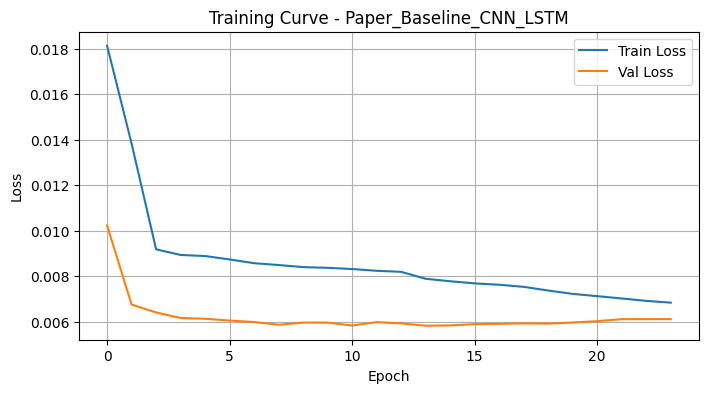

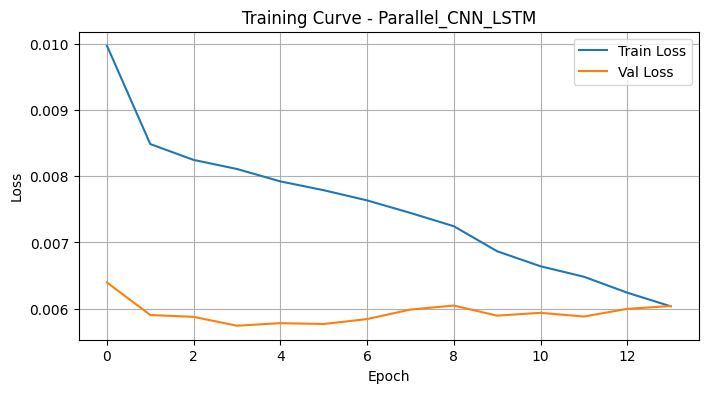

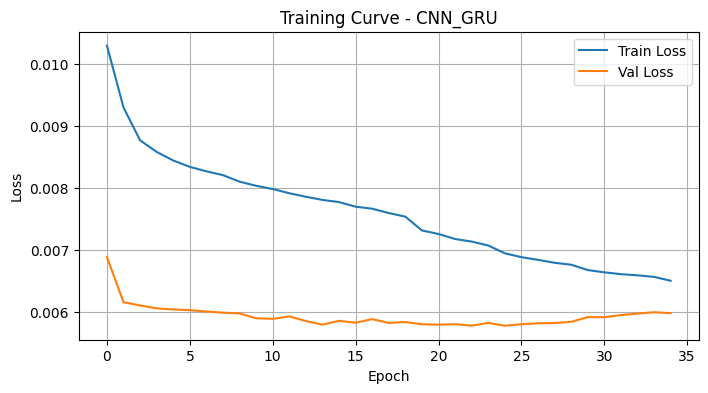

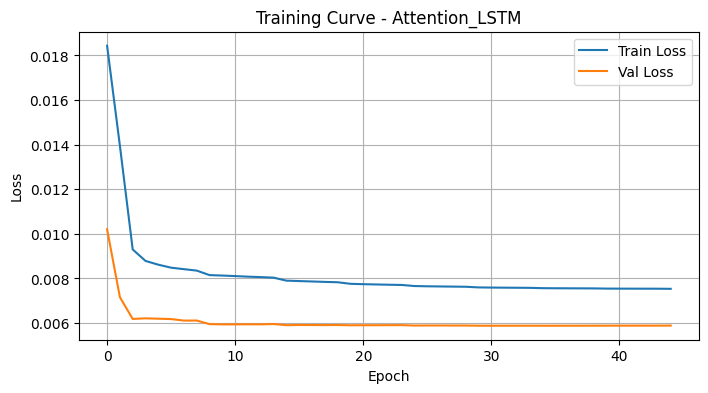

In [ ]:
for name, hist in histories.items():
    plt.figure(figsize=(8, 4))
    plt.plot(hist["loss"], label="Train Loss")
    plt.plot(hist["val_loss"], label="Val Loss")
    plt.title(f"Training Curve - {name}")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

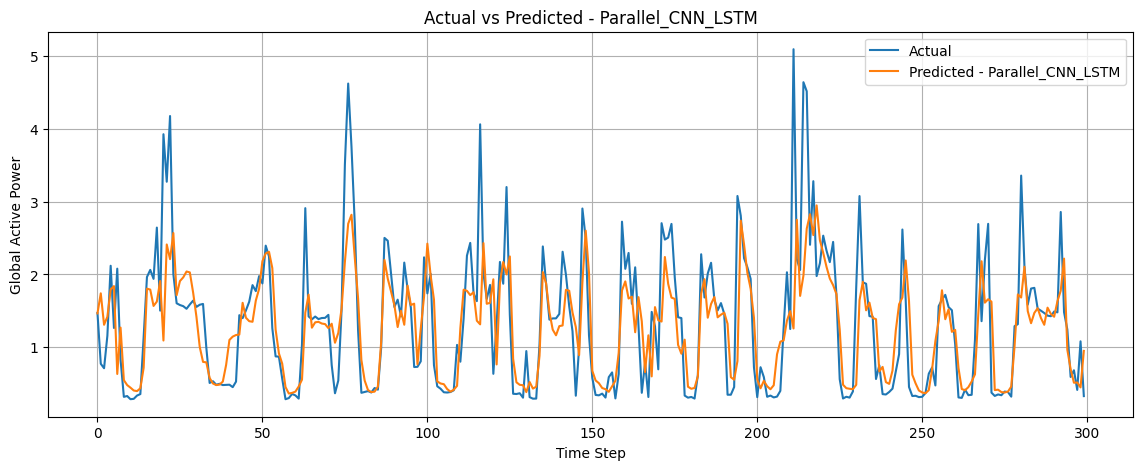

In [ ]:
best_preds = predictions_dict[best_model_name]
y_test_actual = y_scaler.inverse_transform(y_test.reshape(-1, 1))

plt.figure(figsize=(14, 5))
plt.plot(y_test_actual[:300], label="Actual")
plt.plot(best_preds[:300], label=f"Predicted - {best_model_name}")
plt.title(f"Actual vs Predicted - {best_model_name}")
plt.xlabel("Time Step")
plt.ylabel("Global Active Power")
plt.legend()
plt.grid(True)
plt.show()

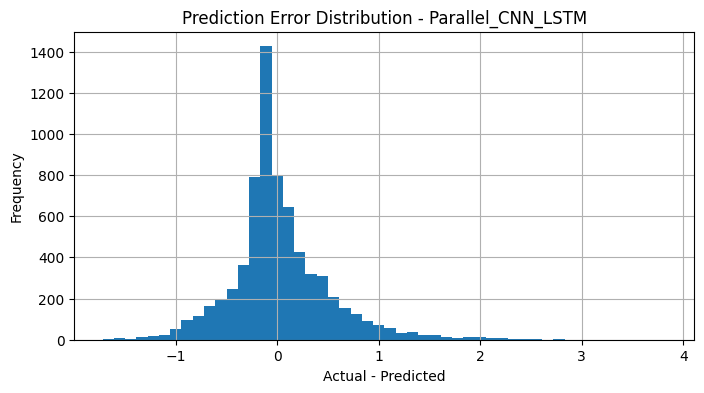

Mean error: 0.022139988630713217
Std of error: 0.48717802217513634


In [ ]:
errors = y_test_actual.flatten() - best_preds.flatten()

plt.figure(figsize=(8, 4))
plt.hist(errors, bins=50)
plt.title(f"Prediction Error Distribution - {best_model_name}")
plt.xlabel("Actual - Predicted")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

print("Mean error:", np.mean(errors))
print("Std of error:", np.std(errors))

In [ ]:
pred_df = pd.DataFrame({
    "Actual": y_test_actual.flatten(),
    "Predicted": best_preds.flatten(),
    "Error": y_test_actual.flatten() - best_preds.flatten()
})

pred_path = f"saved_models/{best_model_name}_test_predictions.csv"
pred_df.to_csv(pred_path, index=False)
print("Saved:", pred_path)

Saved: saved_models/Parallel_CNN_LSTM_test_predictions.csv


In [ ]:
print("\nGenerating SHAP for the selected best model...")

n_timesteps = X_train.shape[1]
n_features = X_train.shape[2]

X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

rng = np.random.default_rng(42)
bg_idx = rng.choice(X_train_flat.shape[0], size=min(50, X_train_flat.shape[0]), replace=False)
background_flat = X_train_flat[bg_idx]

X_explain_flat = X_test_flat[:20]

def predict_fn_best(x_flat):
    x_3d = x_flat.reshape(-1, n_timesteps, n_features)
    preds = best_model.predict(x_3d, verbose=0)
    return preds.reshape(-1, 1)


Generating SHAP for the selected best model...


In [ ]:
explainer = shap.KernelExplainer(predict_fn_best, background_flat)
shap_values = explainer.shap_values(X_explain_flat, nsamples=100)

if isinstance(shap_values, list):
    shap_values = shap_values[0]

shap_values = np.array(shap_values)

if shap_values.ndim == 3:
    shap_values = shap_values[:, :, 0]

print("SHAP values calculated successfully.")
print("Raw SHAP shape:", shap_values.shape)

  0%|          | 0/20 [00:00<?, ?it/s]

SHAP values calculated successfully.
Raw SHAP shape: (20, 72)


In [ ]:
shap_values_3d = shap_values.reshape(X_explain_flat.shape[0], n_timesteps, n_features)
X_explain_3d = X_explain_flat.reshape(X_explain_flat.shape[0], n_timesteps, n_features)

print("Reshaped SHAP shape:", shap_values_3d.shape)

Reshaped SHAP shape: (20, 24, 3)


                 Feature  Mean_Abs_SHAP
0       Global_intensity       0.003090
1                Voltage       0.001051
2  Global_reactive_power       0.000376


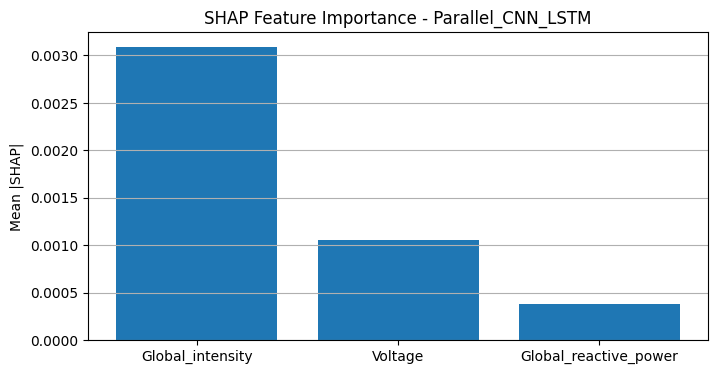

In [ ]:
feature_importance = np.mean(np.abs(shap_values_3d), axis=(0, 1))

feature_df = pd.DataFrame({
    "Feature": features,
    "Mean_Abs_SHAP": feature_importance
}).sort_values(by="Mean_Abs_SHAP", ascending=False).reset_index(drop=True)

print(feature_df)

feature_df.to_csv(f"saved_models/{best_model_name}_shap_feature_importance.csv", index=False)

plt.figure(figsize=(8, 4))
plt.bar(feature_df["Feature"], feature_df["Mean_Abs_SHAP"])
plt.title(f"SHAP Feature Importance - {best_model_name}")
plt.ylabel("Mean |SHAP|")
plt.grid(True, axis="y")
plt.show()

     Lag  Mean_Abs_SHAP
0   t-24       0.001440
1   t-23       0.002051
2   t-22       0.001115
3   t-21       0.000333
4   t-20       0.000236
5   t-19       0.000273
6   t-18       0.000350
7   t-17       0.000857
8   t-16       0.000514
9   t-15       0.000721
10  t-14       0.000267
11  t-13       0.000682
12  t-12       0.000831
13  t-11       0.000369
14  t-10       0.000243
15   t-9       0.000246
16   t-8       0.001066
17   t-7       0.000734
18   t-6       0.000293
19   t-5       0.000512
20   t-4       0.000591
21   t-3       0.000614
22   t-2       0.002409
23   t-1       0.019390


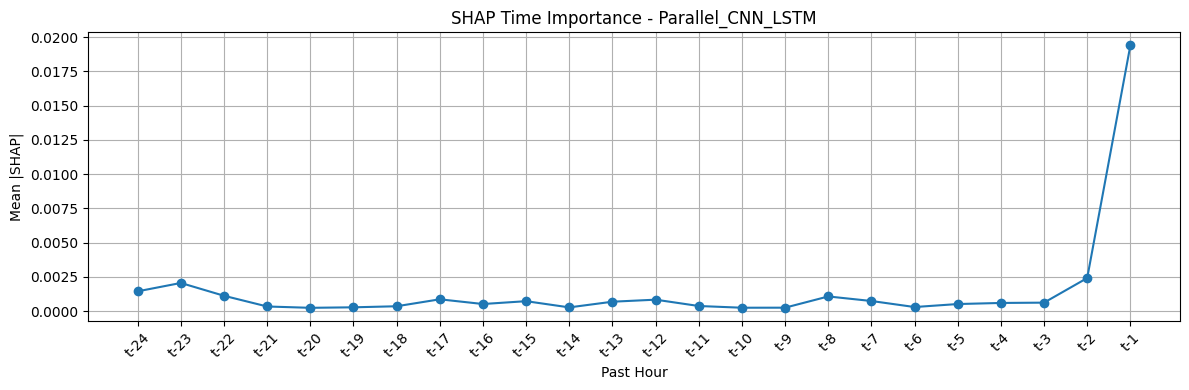

In [ ]:
time_importance = np.mean(np.abs(shap_values_3d), axis=(0, 2))

lag_labels = [f"t-{n_timesteps - i}" for i in range(n_timesteps)]

time_df = pd.DataFrame({
    "Lag": lag_labels,
    "Mean_Abs_SHAP": time_importance
})

print(time_df)

time_df.to_csv(f"saved_models/{best_model_name}_shap_time_importance.csv", index=False)

plt.figure(figsize=(12, 4))
plt.plot(range(n_timesteps), time_importance, marker="o")
plt.xticks(range(n_timesteps), lag_labels, rotation=45)
plt.title(f"SHAP Time Importance - {best_model_name}")
plt.xlabel("Past Hour")
plt.ylabel("Mean |SHAP|")
plt.grid(True)
plt.tight_layout()
plt.show()

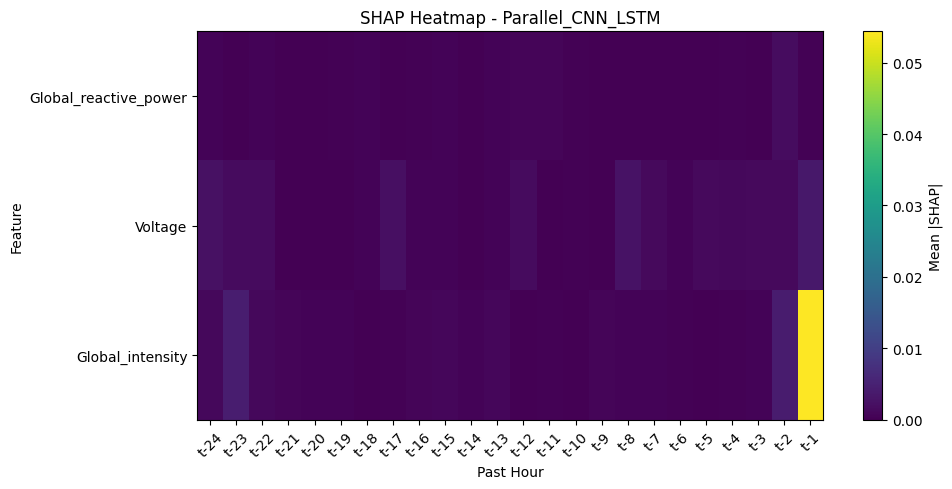

In [ ]:
heatmap_vals = np.mean(np.abs(shap_values_3d), axis=0)

plt.figure(figsize=(10, 5))
plt.imshow(heatmap_vals.T, aspect="auto")
plt.colorbar(label="Mean |SHAP|")
plt.yticks(range(n_features), features)
plt.xticks(range(n_timesteps), lag_labels, rotation=45)
plt.title(f"SHAP Heatmap - {best_model_name}")
plt.xlabel("Past Hour")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

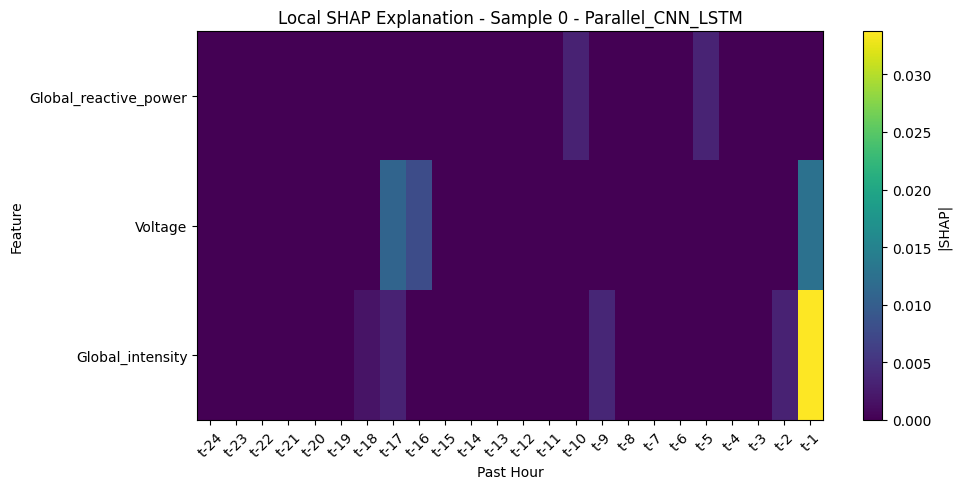

In [ ]:
sample_id = 0
local_vals = shap_values_3d[sample_id]

plt.figure(figsize=(10, 5))
plt.imshow(np.abs(local_vals).T, aspect="auto")
plt.colorbar(label="|SHAP|")
plt.yticks(range(n_features), features)
plt.xticks(range(n_timesteps), lag_labels, rotation=45)
plt.title(f"Local SHAP Explanation - Sample {sample_id} - {best_model_name}")
plt.xlabel("Past Hour")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [ ]:
np.save(f"saved_models/{best_model_name}_shap_values.npy", shap_values_3d)
np.save(f"saved_models/{best_model_name}_shap_inputs.npy", X_explain_3d)

print("Saved SHAP arrays.")

Saved SHAP arrays.


In [ ]:
try:
    from google.colab import files
    files.download("energy_models_and_results.zip")
except Exception as e:
    print("Download block skipped.")
    print("Zip file exists as: energy_models_and_results.zip")
    print("Reason:", e)

Download block skipped.
Zip file exists as: energy_models_and_results.zip
Reason: Cannot find file: energy_models_and_results.zip


In [ ]:
import os
import shutil
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Source folder in Colab runtime
src_folder = "saved_models"

# Destination folder in Google Drive
dst_folder = "/content/drive/MyDrive/saved_models"

# Create parent path if needed
os.makedirs(os.path.dirname(dst_folder), exist_ok=True)

# If destination already exists, remove it first
if os.path.exists(dst_folder):
    shutil.rmtree(dst_folder)

# Copy entire folder
shutil.copytree(src_folder, dst_folder)

print("Entire folder saved to Drive:", dst_folder)

Mounted at /content/drive
Entire folder saved to Drive: /content/drive/MyDrive/saved_models
